# CreditIQ — WOE & IV Feature Analysis

This notebook documents the Weight of Evidence (WOE) and Information Value (IV)
analysis used in the CreditIQ credit-risk modeling pipeline.

The actual WOE/IV implementation is maintained in:

`src/features/woe_encoder.py`

This notebook is used to:
- understand the WOE/IV results
- inspect feature importance
- identify useful and weak predictors
- document the feature-selection decision
- verify the final model-ready datasets

## 1. Why WOE and IV?

CreditIQ is a binary credit-risk prediction problem where:

- `TARGET = 0` → applicant did not experience payment difficulty
- `TARGET = 1` → applicant experienced payment difficulty

WOE (Weight of Evidence) transforms features into a form that represents
the relationship between a feature value/bin and the target outcome.

IV (Information Value) measures how useful a feature is for separating
the two target classes.

We use IV to help remove features that provide very little predictive signal.

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT)
print("Processed data:", PROCESSED_DIR)

Project root: c:\Users\Vaishnavi chavan\Documents\CreditIQ
Processed data: c:\Users\Vaishnavi chavan\Documents\CreditIQ\data\processed


In [4]:
woe_iv = pd.read_csv(
    PROCESSED_DIR / "woe_iv_report.csv"
)

print(
    f"Total features evaluated: {len(woe_iv)}"
)

woe_iv.head(10)

Total features evaluated: 183


,feature,iv
0,EXT_SOURCE_3,0.316128
1,EXT_SOURCE_2,0.293099
2,EXT_SOURCE_1,0.145646
3,YEARS_EMPLOYED,0.106663
4,DAYS_EMPLOYED,0.106595
5,OCCUPATION_TYPE,0.091949
6,ANNUITY_TO_CREDIT,0.087498
7,AMT_GOODS_PRICE,0.086601
8,DAYS_BIRTH,0.081812
9,ORGANIZATION_TYPE,0.075919


## 2. Information Value Summary

The WOE/IV pipeline evaluated 183 features.

We used an IV threshold of 0.02 for feature selection.

Features with:

- `IV >= 0.02` → selected
- `IV < 0.02` → removed

The threshold is used as a practical feature-selection rule rather than
treating IV as the only measure of model quality.

In [5]:
IV_THRESHOLD = 0.02

selected = woe_iv[
    woe_iv["iv"] >= IV_THRESHOLD
].copy()

removed = woe_iv[
    woe_iv["iv"] < IV_THRESHOLD
].copy()

print("=" * 50)
print("WOE / IV SUMMARY")
print("=" * 50)

print(
    f"Total features evaluated : {len(woe_iv)}"
)

print(
    f"IV threshold              : {IV_THRESHOLD}"
)

print(
    f"Features selected         : {len(selected)}"
)

print(
    f"Features removed          : {len(removed)}"
)

WOE / IV SUMMARY
Total features evaluated : 183
IV threshold              : 0.02
Features selected         : 79
Features removed          : 104


## 3. Top Features by Information Value

The following features have the highest IV values in our dataset.

Higher IV indicates a stronger relationship with the target according
to the WOE/IV analysis.

In [6]:
top_10 = (
    woe_iv
    .sort_values("iv", ascending=False)
    .head(10)
)

top_10

,feature,iv
0,EXT_SOURCE_3,0.316128
1,EXT_SOURCE_2,0.293099
2,EXT_SOURCE_1,0.145646
3,YEARS_EMPLOYED,0.106663
4,DAYS_EMPLOYED,0.106595
5,OCCUPATION_TYPE,0.091949
6,ANNUITY_TO_CREDIT,0.087498
7,AMT_GOODS_PRICE,0.086601
8,DAYS_BIRTH,0.081812
9,ORGANIZATION_TYPE,0.075919


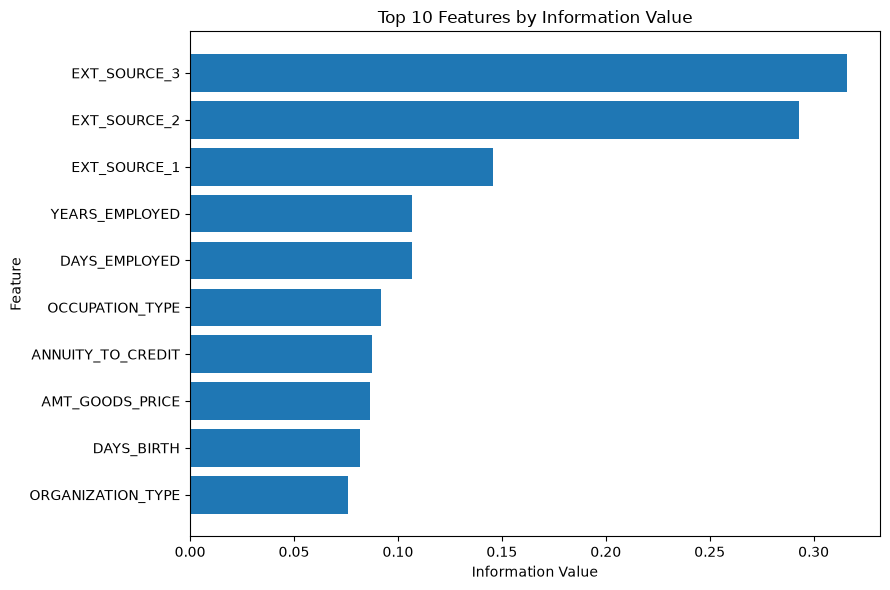

In [7]:
top_10_plot = (
    woe_iv
    .sort_values("iv", ascending=False)
    .head(10)
    .sort_values("iv")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_10_plot["feature"],
    top_10_plot["iv"]
)

plt.xlabel("Information Value")
plt.ylabel("Feature")
plt.title("Top 10 Features by Information Value")

plt.tight_layout()
plt.show()

## 4. Weak Features

We also inspect features with very low IV.

Features with IV below 0.02 were not selected for the final model-ready
feature set.

Some features have an IV of exactly 0, indicating that the WOE/IV analysis
did not find useful separation between the target classes for those features.

In [8]:
bottom_10 = (
    woe_iv
    .sort_values("iv", ascending=True)
    .head(10)
)

bottom_10

,feature,iv
182,REG_CITY_NOT_WORK_CITY,0.0
150,FLAG_DOCUMENT_6,0.0
151,FLAG_DOCUMENT_9,0.0
152,FLAG_DOCUMENT_8,0.0
153,FLAG_DOCUMENT_7,0.0
154,FLAG_DOCUMENT_10,0.0
155,REG_REGION_NOT_WORK_REGION,0.0
156,FLAG_DOCUMENT_5,0.0
157,FLAG_DOCUMENT_4,0.0
158,FLAG_DOCUMENT_11,0.0


## 5. IV Distribution

The IV distribution helps us understand how many features provide
meaningful predictive signal and how many contribute relatively little.

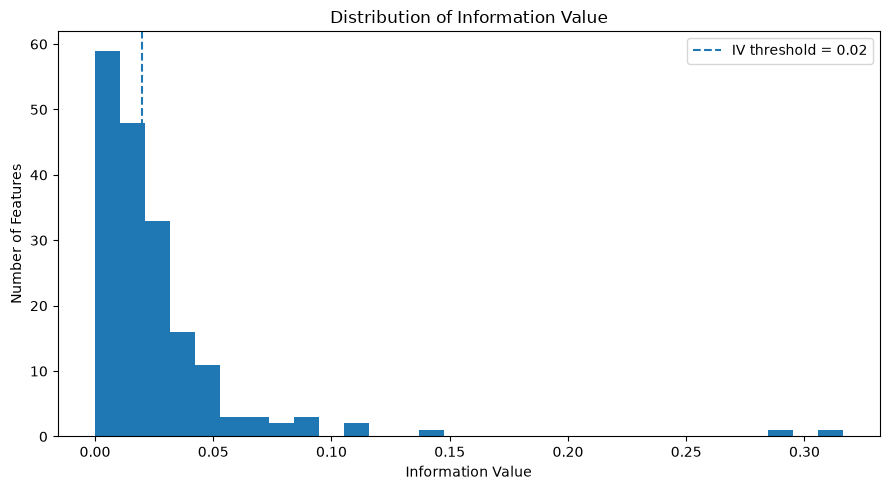

In [9]:
plt.figure(figsize=(9, 5))

plt.hist(
    woe_iv["iv"],
    bins=30
)

plt.axvline(
    IV_THRESHOLD,
    linestyle="--",
    label=f"IV threshold = {IV_THRESHOLD}"
)

plt.xlabel("Information Value")
plt.ylabel("Number of Features")
plt.title("Distribution of Information Value")

plt.legend()
plt.tight_layout()
plt.show()

In [10]:
print(
    "Features with IV > 0.50:",
    (woe_iv["iv"] > 0.50).sum()
)

print(
    "Features with IV > 0.30:",
    (woe_iv["iv"] > 0.30).sum()
)

Features with IV > 0.50: 0
Features with IV > 0.30: 1


## 6. High-IV Review

Extremely high IV values can sometimes indicate leakage or other unusual
relationships.

In this analysis:

- No feature has IV > 0.50
- One feature has IV > 0.30

Therefore, the IV results do not show a large number of suspiciously
high-IV features.

Potential leakage was also considered separately in the data-leakage
analysis and through the time-based dataset split.

In [11]:
selected_features = pd.read_csv(
    PROCESSED_DIR / "selected_features.csv"
)

removed_features = pd.read_csv(
    PROCESSED_DIR / "removed_features.csv"
)

print(
    "Selected features:",
    len(selected_features)
)

print(
    "Removed features:",
    len(removed_features)
)

Selected features: 79
Removed features: 104


## 7. Final Feature Selection

Based on the IV threshold of 0.02:

- 79 features were selected
- 104 features were removed
- 183 features were evaluated in total

The selected features are used in the final model-ready datasets.

In [12]:
train_final = pd.read_parquet(
    PROCESSED_DIR / "train_final.parquet"
)

validation_final = pd.read_parquet(
    PROCESSED_DIR / "validation_final.parquet"
)

test_final = pd.read_parquet(
    PROCESSED_DIR / "test_final.parquet"
)

print("TRAIN      :", train_final.shape)
print("VALIDATION :", validation_final.shape)
print("TEST       :", test_final.shape)

TRAIN      : (215257, 81)
VALIDATION : (46127, 81)
TEST       : (46127, 81)


In [13]:
print("Training target distribution:")
print(train_final["TARGET"].value_counts())

print("\nValidation target distribution:")
print(validation_final["TARGET"].value_counts())

print("\nTest target distribution:")
print(test_final["TARGET"].value_counts())

Training target distribution:
TARGET
0    199444
1     15813
Name: count, dtype: int64

Validation target distribution:
TARGET
0    41795
1     4332
Name: count, dtype: int64

Test target distribution:
TARGET
0    41447
1     4680
Name: count, dtype: int64


In [14]:
feature_columns = [
    col
    for col in train_final.columns
    if col not in ["SK_ID_CURR", "TARGET"]
]

print(
    "Final model features:",
    len(feature_columns)
)

print(
    "\nFirst 20 final features:"
)

print(
    feature_columns[:20]
)

Final model features: 79

First 20 final features:
['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'YEARS_EMPLOYED', 'DAYS_EMPLOYED', 'OCCUPATION_TYPE', 'ANNUITY_TO_CREDIT', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'ORGANIZATION_TYPE', 'bureau_most_recent_days', 'previous_avg_credit_to_application_ratio', 'installment_ontime_ratio', 'NAME_INCOME_TYPE', 'installment_payment_ratio', 'bureau_avg_debt', 'bureau_oldest_days', 'CODE_GENDER', 'previous_refused_count', 'NAME_EDUCATION_TYPE']


In [15]:
train_features = set(
    train_final.columns
)

validation_features = set(
    validation_final.columns
)

test_features = set(
    test_final.columns
)

print(
    "Train/Validation columns match:",
    train_features == validation_features
)

print(
    "Train/Test columns match:",
    train_features == test_features
)

Train/Validation columns match: True
Train/Test columns match: True


In [24]:
import pandas as pd

woe_report = pd.read_csv(
    "../data/processed/woe_iv_report.csv"
)

# Features where the handbook gives a clear credit-risk direction
candidate_features = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "DEBT_TO_INCOME",
    "CREDIT_TO_INCOME",
    "ANNUITY_TO_CREDIT",
    "YEARS_EMPLOYED",
]

print(
    woe_report[
        woe_report["feature"].isin(candidate_features)
    ].sort_values("iv", ascending=False)
)

               feature        iv
0         EXT_SOURCE_3  0.316128
1         EXT_SOURCE_2  0.293099
2         EXT_SOURCE_1  0.145646
3       YEARS_EMPLOYED  0.106663
6    ANNUITY_TO_CREDIT  0.087498
121   CREDIT_TO_INCOME  0.011653
132     DEBT_TO_INCOME  0.006768


In [25]:
import pandas as pd
import numpy as np

train = pd.read_parquet(
    "../data/processed/train.parquet"
)

print("Train shape:", train.shape)

Train shape: (215257, 185)


In [26]:
feature = "ANNUITY_TO_CREDIT"
temp = train[[feature, "TARGET"]].copy()

temp[feature] = temp[feature].where(
    temp[feature].notna(),
    "__MISSING__"
)

temp["bin"] = pd.qcut(
    train[feature],
    q=10,
    duplicates="drop"
)

temp["bin"] = temp["bin"].astype(object)

temp.loc[
    train[feature].isna(),
    "bin"
] = "__MISSING__"

grouped = (
    temp.groupby(
        "bin",
        dropna=False,
        observed=False
    )["TARGET"]
    .agg(
        total="count",
        bad="sum"
    )
    .reset_index()
)

grouped["good"] = (
    grouped["total"] - grouped["bad"]
)

epsilon = 1e-6

total_good = grouped["good"].sum()
total_bad = grouped["bad"].sum()

grouped["dist_good"] = (
    (grouped["good"] + epsilon)
    / (total_good + epsilon * len(grouped))
)

grouped["dist_bad"] = (
    (grouped["bad"] + epsilon)
    / (total_bad + epsilon * len(grouped))
)

grouped["woe"] = np.log(
    grouped["dist_good"]
    / grouped["dist_bad"]
)

grouped[
    ["bin", "good", "bad", "woe"]
]

,bin,good,bad,woe
0,"(0.0211, 0.0294]",20955,1286,0.256140
1,"(0.0294, 0.033]",19419,1390,0.102247
2,"(0.033, 0.0391]",20052,1483,0.069561
3,"(0.0391, 0.0443]",20554,964,0.525018
4,"(0.0443, 0.05]",36177,3417,-0.175041
5,"(0.05, 0.0512]",3267,306,-0.166659
6,"(0.0512, 0.0563]",19527,1925,-0.217829
7,"(0.0563, 0.0686]",19478,1999,-0.258063
8,"(0.0686, 0.0974]",19406,2126,-0.323361
9,"(0.0974, 0.124]",20601,917,0.577286


## Monotonicity Inspection

Before applying monotonic constraints to the WOE-encoded features, selected
features were inspected using their training-set WOE values.

The inspection showed:

| Feature | WOE Direction | Constraint |
|---|---|---:|
| EXT_SOURCE_1 | WOE increases → risk decreases | -1 |
| EXT_SOURCE_2 | WOE increases → risk decreases | -1 |
| EXT_SOURCE_3 | WOE increases → risk decreases | -1 |
| YEARS_EMPLOYED | No sufficiently consistent monotonic pattern | 0 |
| ANNUITY_TO_CREDIT | No clear monotonic pattern | 0 |

Only features with a defensible and sufficiently consistent direction were
assigned monotonic constraints. Other features remain unconstrained.

The final constraints are maintained separately in
`src/models/monotonic_config.py`.

## 8. Final WOE/IV Outcome

The WOE/IV pipeline evaluated 183 candidate features.

Using an IV threshold of 0.02:

- 79 features were selected.
- 104 features were removed.

The selected features were used to create the final model-ready datasets:

- Train: 215,257 rows × 81 columns
- Validation: 46,127 rows × 81 columns
- Test: 46,127 rows × 81 columns

Each dataset contains:

- 79 selected model features
- `SK_ID_CURR`
- `TARGET`

The final datasets are now ready for model training.

The actual WOE transformation and feature-selection logic is maintained
in `src/features/woe_encoder.py`, while this notebook documents the
analysis and results.

# Conclusion

WOE/IV provided a structured way to evaluate the predictive usefulness
of the engineered features.

The analysis reduced the feature space from 183 evaluated features to
79 selected features using an IV threshold of 0.02.

The resulting WOE-based datasets are used as input to the CreditIQ
baseline Logistic Regression and subsequent XGBoost models.

The test dataset remains reserved for final model evaluation.